# EDA — Predicting Student Health Risk (Playground Series S6E7)

Target: `health_condition` (`at-risk` / `unhealthy` / `fit`), scored on **balanced accuracy**.

Goals for this notebook:
1. Confirm the target class imbalance and per-column missingness rates.
2. Look at numeric feature distributions split by target class.
3. Look at categorical feature distributions split by target class.
4. Check numeric feature correlations.
5. Flag anything (leakage, surprising skew) that should influence feature engineering and modeling choices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

pd.set_option('display.max_columns', 50)

DATA_DIR = Path('/kaggle/input/playground-series-s6e7')
if not (DATA_DIR / 'train.csv').exists():
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits:
        DATA_DIR = Path(hits[0]).parent
    else:
        DATA_DIR = Path('..') / 'data'  # local fallback for testing outside Kaggle
IMG_DIR = Path('/kaggle/working/images') if Path('/kaggle/working').exists() else Path('..') / 'docs' / 'images'
IMG_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

TARGET = 'health_condition'
NUMERIC_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
                 'step_count', 'exercise_duration', 'water_intake']
CATEGORICAL_COLS = ['diet_type', 'stress_level', 'sleep_quality',
                     'physical_activity_level', 'smoking_alcohol', 'gender']

print('train shape:', train.shape)
print('test shape:', test.shape)
train.head()

train shape: (690088, 15)
test shape: (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 1. Target distribution

,count,share
health_condition,,
at-risk,592561,0.858675
unhealthy,57724,0.083647
fit,39803,0.057678


Majority-class-only balanced accuracy floor: 0.333


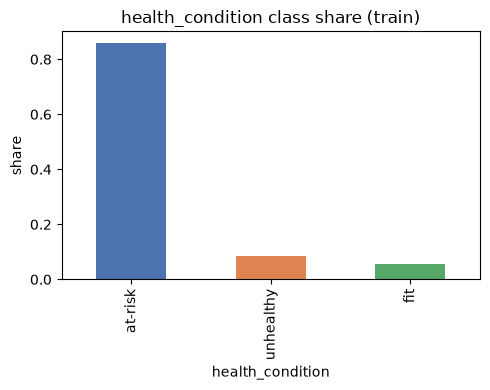

In [2]:
target_counts = train[TARGET].value_counts()
target_share = train[TARGET].value_counts(normalize=True)
display(pd.DataFrame({'count': target_counts, 'share': target_share}))

floor_balanced_accuracy = 1 / train[TARGET].nunique()
print(f'Majority-class-only balanced accuracy floor: {floor_balanced_accuracy:.3f}')

fig, ax = plt.subplots(figsize=(5, 4))
target_share.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('health_condition class share (train)')
ax.set_ylabel('share')
fig.tight_layout()
fig.savefig(IMG_DIR / 'v0.1-target-distribution.png', dpi=120)
plt.show()

## 2. Missingness — train vs. test

We check per-column missingness rates and compare train vs. test consistency (no missingness-pattern leakage signal expected).

In [3]:
feature_cols = NUMERIC_COLS + CATEGORICAL_COLS
missing = pd.DataFrame({
    'train_missing_pct': train[feature_cols].isnull().mean() * 100,
    'test_missing_pct': test[feature_cols].isnull().mean() * 100,
})
missing['abs_diff_pct'] = (missing['train_missing_pct'] - missing['test_missing_pct']).abs()
missing.sort_values('train_missing_pct', ascending=False)

,train_missing_pct,test_missing_pct,abs_diff_pct
stress_level,12.000064,11.999878,0.000185
sleep_duration,11.012943,11.012906,0.000037
sleep_quality,8.452690,8.452662,0.000029
calorie_expenditure,7.658878,7.659094,0.000216
water_intake,6.300211,6.300190,0.000021
physical_activity_level,5.306715,5.306793,0.000079
smoking_alcohol,4.141791,4.141632,0.000159
gender,3.097141,3.097179,0.000038
step_count,2.016554,2.016548,0.000007
bmi,2.013946,2.013843,0.000103


## 3. Numeric features — summary stats and distribution by target class

In [4]:
train[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


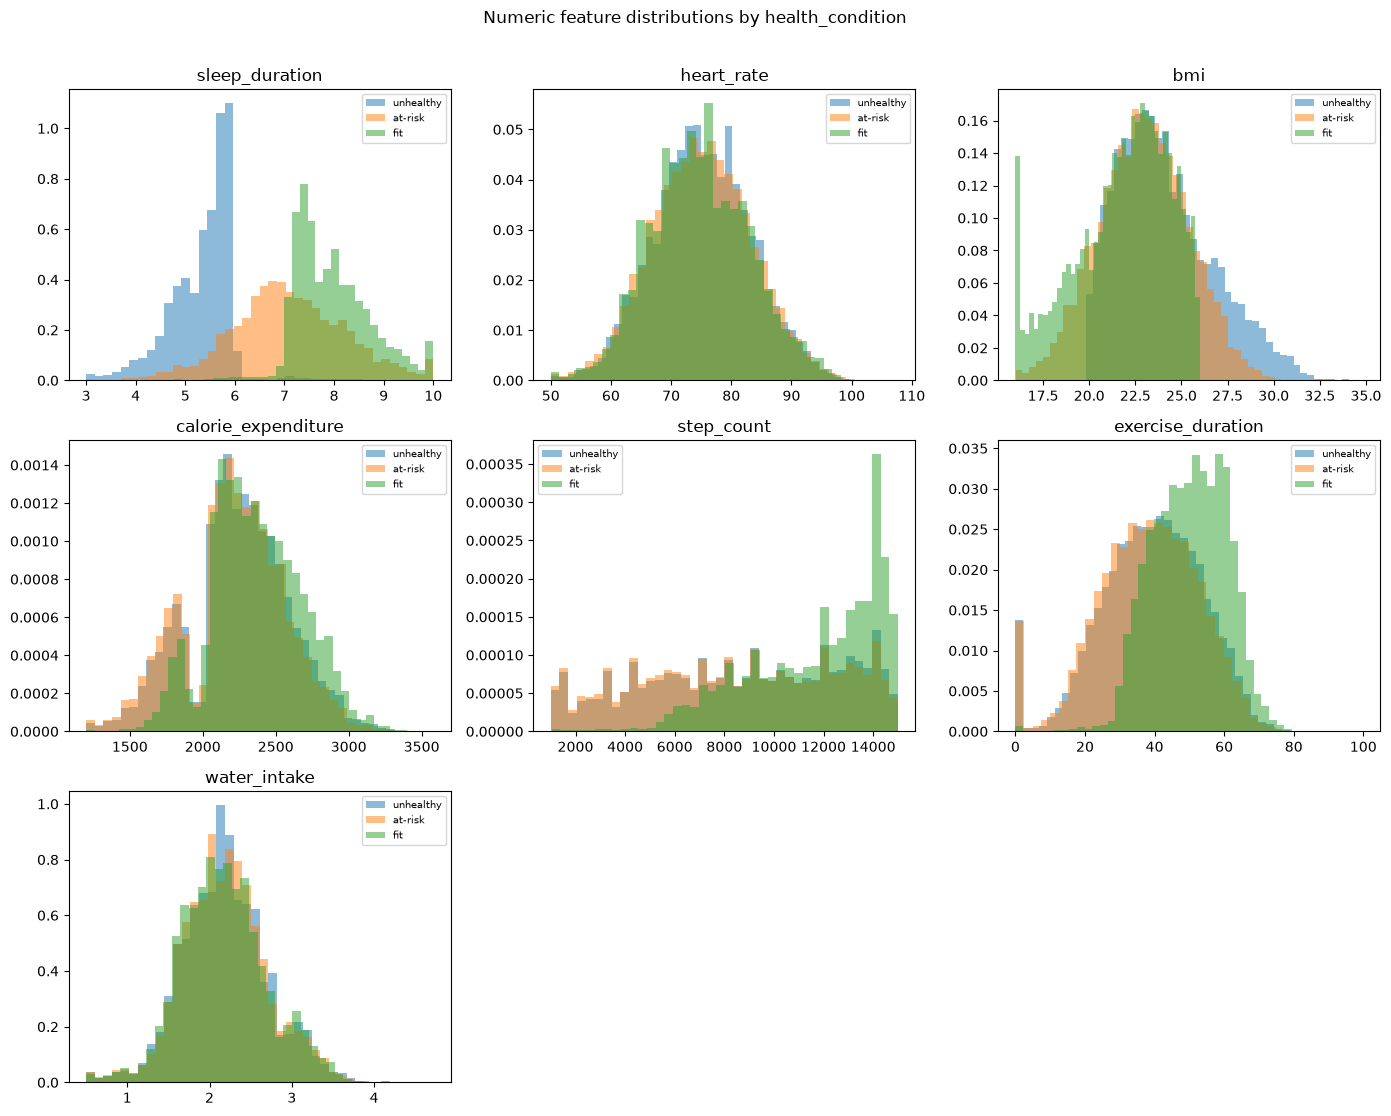

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
classes = train[TARGET].dropna().unique()
for ax, col in zip(axes.flat, NUMERIC_COLS):
    for cls in classes:
        subset = train.loc[train[TARGET] == cls, col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, density=True, label=cls)
    ax.set_title(col)
    ax.legend(fontsize=7)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis('off')
fig.suptitle('Numeric feature distributions by health_condition', y=1.01)
fig.tight_layout()
fig.savefig(IMG_DIR / 'v0.1-numeric-by-class.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Categorical features — class mix by target

In [6]:
for col in CATEGORICAL_COLS:
    ct = pd.crosstab(train[col], train[TARGET], normalize='index')
    print(f'\n--- {col} (row-normalized share of health_condition) ---')
    display(ct)


--- diet_type (row-normalized share of health_condition) ---


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,0.851394,0.061193,0.087413
non-veg,0.867802,0.051586,0.080612
veg,0.856679,0.060355,0.082966



--- stress_level (row-normalized share of health_condition) ---


health_condition,at-risk,fit,unhealthy
stress_level,,,
high,0.717817,0.003511,0.278672
low,0.796670,0.200557,0.002773
medium,0.993935,0.002998,0.003067



--- sleep_quality (row-normalized share of health_condition) ---


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,0.743085,0.171603,0.085312
moderate,0.911482,0.003108,0.085409
sedentary,0.917273,0.002416,0.080311



--- smoking_alcohol (row-normalized share of health_condition) ---


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,0.866846,0.078552,0.054602
occasional,0.858541,0.057843,0.083616
yes,0.851017,0.037013,0.111970



--- gender (row-normalized share of health_condition) ---


health_condition,at-risk,fit,unhealthy
gender,,,
female,0.857390,0.057067,0.085543
male,0.856971,0.062568,0.080461
other,0.862063,0.052928,0.085009


## 5. Numeric feature correlations

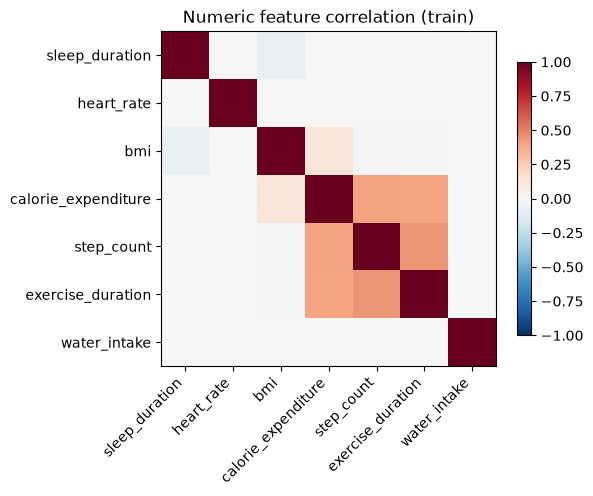

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
sleep_duration,1.000000,-0.005183,-0.074576,-0.004075,0.004082,0.001708,0.000519
heart_rate,-0.005183,1.000000,0.000612,-0.003967,-0.005486,-0.005679,0.000192
bmi,-0.074576,0.000612,1.000000,0.117624,-0.020548,-0.020289,0.000638
calorie_expenditure,-0.004075,-0.003967,0.117624,1.000000,0.400102,0.393592,0.001534
step_count,0.004082,-0.005486,-0.020548,0.400102,1.000000,0.438236,-0.000588
exercise_duration,0.001708,-0.005679,-0.020289,0.393592,0.438236,1.000000,0.002199
water_intake,0.000519,0.000192,0.000638,0.001534,-0.000588,0.002199,1.000000


In [7]:
corr = train[NUMERIC_COLS].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=45, ha='right')
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Numeric feature correlation (train)')
fig.tight_layout()
fig.savefig(IMG_DIR / 'v0.1-numeric-correlation.png', dpi=120)
plt.show()
corr

## 6. `id` vs. target sanity check

The competition's Data Explorer view shows `health_condition` binned uniformly across `id` ranges in the sample submission. Here we check whether `id` carries any ordering signal in the real train labels, which would indicate a generation artifact worth exploiting or avoiding.

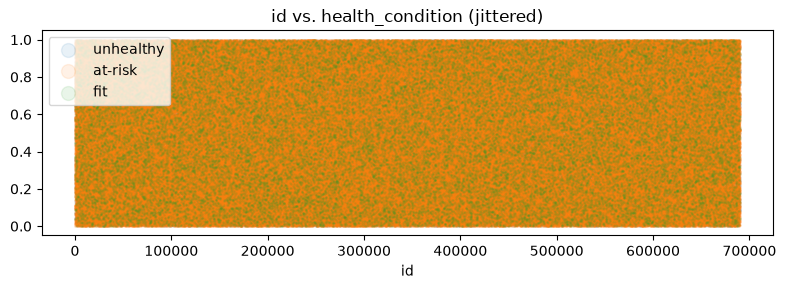

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
for cls in classes:
    ax.scatter(train.loc[train[TARGET] == cls, 'id'],
               np.random.uniform(0, 1, (train[TARGET] == cls).sum()),
               s=1, alpha=0.1, label=cls)
ax.set_title('id vs. health_condition (jittered)')
ax.set_xlabel('id')
ax.legend(markerscale=10)
fig.tight_layout()
plt.show()

## Findings summary

1. **Target imbalance confirmed**: `at-risk` 85.87%, `unhealthy` 8.36%, `fit` 5.77%.
   Majority-class-only balanced accuracy floor = 0.333.

2. **Missingness matches train/test almost exactly** (largest gap 0.0002pp, on `stress_level`).
   No missingness-pattern leakage signal to chase; imputation strategy just needs to be
   consistent between train and test, not train-specific.

3. **`stress_level` and `physical_activity_level` are unusually strong signals** — closer to
   near-deterministic than a typical Playground feature:
   - `stress_level == medium` -> 99.4% `at-risk` (`fit`/`unhealthy` combined < 0.6%).
   - `stress_level == low` -> 20.1% `fit` (vs. ~5.8% baseline); `stress_level == high` -> 27.9%
     `unhealthy` (vs. ~8.4% baseline).
   - `physical_activity_level == active` -> 17.2% `fit` vs. ~0.2-0.3% for `moderate`/`sedentary`.
   These two categoricals look like they encode most of the separability between the three
   classes on their own. **Action for modeling**: make sure the baseline model can actually
   split on these (native categorical support, not silently one-hot-collapsed) and don't
   let missing values in these two columns (12.0% / 5.3%) get imputed in a way that erases
   the signal — treating `NaN` as its own explicit category is likely better than mode-fill
   here, worth an ablation.

4. **`sleep_quality` and `smoking_alcohol` are secondary signals**: `poor` sleep quality
   raises `unhealthy` share to 13.6% (vs. 8.3% baseline); `smoking_alcohol == yes` raises
   `unhealthy` to 11.2% (vs. 5.5% for `no`). Weaker than (3) but still worth keeping as
   native categoricals rather than dropping.

5. **`diet_type` and `gender` show almost no class separation** — near-identical
   conditional distributions across categories. Not leakage-prone, just low signal;
   keep them in for now (cheap to include in a GBM) rather than dropping.

6. **Numeric features show mild inter-correlation** among `calorie_expenditure`,
   `step_count`, and `exercise_duration` (0.39-0.44) — expected, all proxy "activity
   volume". No pair is collinear enough to warrant dropping either. `bmi` vs.
   `calorie_expenditure` (0.12) is the next largest, still weak.

7. **No obvious `id`-ordering artifact** in the jittered scatter — `id` does not look
   like a leakage feature (consistent with `id` being an arbitrary row index).

### Takeaways for modeling
- The baseline model should treat `stress_level`, `physical_activity_level`, `sleep_quality`,
  `smoking_alcohol` as native categoricals with `NaN` as an explicit level, not imputed away.
- Given how much signal (3) alone carries, a quick permutation/feature-importance check
  after an initial fit is worth doing early — if `stress_level` + `physical_activity_level`
  dominate importances, it validates this reading and simplifies where feature-engineering
  effort should go next (interactions involving these two, not the low-signal `diet_type`/`gender`).